<a href="https://colab.research.google.com/github/sinchugowda887/Bank-Fraud-detection/blob/main/supply%20chain%20demand%20forecasting%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.1802
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0969 
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0760
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0784
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0766
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0641
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0617
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0622 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0611
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0596
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0553
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0528
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0509
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0505
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0506
Epoch 16/100
3/3 ━━━━━━━━━━━━

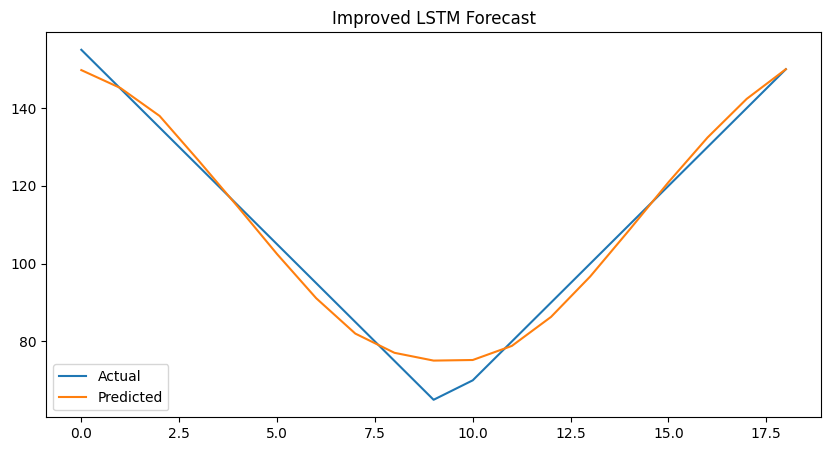

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Sample data (replace with your dataset)
data = np.array([120,130,125,140,150,160,170,180,175,165,
                 155,145,135,125,115,105,95,85,75,65,
                 70,80,90,100,110,120,130,140,150,160]).reshape(-1,1)

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Create dataset
def create_dataset(dataset, time_step=10):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X, y = create_dataset(data_scaled, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Train
model.fit(X, y, epochs=100, batch_size=8, verbose=1)

# Predict
pred = model.predict(X)

# Inverse scaling
pred = scaler.inverse_transform(pred)
y_actual = scaler.inverse_transform(y.reshape(-1,1))

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Improved LSTM Forecast")
plt.show()